# 01 — Data Exploration & NLP Label Extraction

**Project:** DDI-Graph-LLM  
**Phase 1:** Load the Kaggle DDI dataset, explore basic statistics, extract interaction-type labels from description text using regex, and validate coverage.

**Dataset:** [Kaggle Drug-Drug Interactions](https://www.kaggle.com/datasets/mghobashy/drug-drug-interactions)  
**Columns:** `Drug 1`, `Drug 2`, `Interaction Description`


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


## 1. Load Data

In [2]:
df = pd.read_csv("../data/drug_interactions.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Null values:\n{df.isnull().sum()}")
df.head(10)


Shape: (191541, 3)
Columns: ['Drug 1', 'Drug 2', 'Interaction Description']
Null values:
Drug 1                     0
Drug 2                     0
Interaction Description    0
dtype: int64


,Drug 1,Drug 2,Interaction Description
0,Trioxsalen,Verteporfin,Trioxsalen may increase the photosensitizing a...
1,Aminolevulinic acid,Verteporfin,Aminolevulinic acid may increase the photosens...
2,Titanium dioxide,Verteporfin,Titanium dioxide may increase the photosensiti...
3,Tiaprofenic acid,Verteporfin,Tiaprofenic acid may increase the photosensiti...
4,Cyamemazine,Verteporfin,Cyamemazine may increase the photosensitizing ...
5,Temoporfin,Verteporfin,Temoporfin may increase the photosensitizing a...
6,Methoxsalen,Verteporfin,Methoxsalen may increase the photosensitizing ...
7,Hexaminolevulinate,Verteporfin,Hexaminolevulinate may increase the photosensi...
8,Benzophenone,Verteporfin,Benzophenone may increase the photosensitizing...
9,Riboflavin,Verteporfin,Riboflavin may increase the photosensitizing a...


## 2. Basic Statistics

In [3]:
print(f"Total interactions: {len(df):,}")
print(f"Unique Drug 1: {df['Drug 1'].nunique():,}")
print(f"Unique Drug 2: {df['Drug 2'].nunique():,}")

all_drugs = set(df['Drug 1'].unique()) | set(df['Drug 2'].unique())
print(f"Total unique drugs (will become graph nodes): {len(all_drugs):,}")
print(f"Unique interaction descriptions: {df['Interaction Description'].nunique():,}")


Total interactions: 191,541
Unique Drug 1: 1,634
Unique Drug 2: 1,606
Total unique drugs (will become graph nodes): 1,701
Unique interaction descriptions: 191,541


## 3. Interaction Description Template Analysis

DrugBank interaction descriptions follow semi-structured templates. We replace drug names with placeholders to discover the underlying patterns.


In [4]:
def extract_template(desc, drug1, drug2):
    """Replace drug names with placeholders to reveal template structure."""
    return desc.replace(drug1, "DRUG_A").replace(drug2, "DRUG_B")

df['template'] = df.apply(
    lambda r: extract_template(r['Interaction Description'], r['Drug 1'], r['Drug 2']),
    axis=1
)

template_counts = df['template'].value_counts()
print(f"Unique templates: {len(template_counts)}")
print(f"\nTop 20 templates (covering {template_counts.head(20).sum()/len(df):.1%} of data):")
print("=" * 100)
for tmpl, count in template_counts.head(20).items():
    print(f"  [{count:>6,}]  {tmpl[:95]}")


Unique templates: 89

Top 20 templates (covering 93.1% of data):
  [60,720]  The risk or severity of adverse effects can be increased when DRUG_A is combined with DRUG_B.
  [34,313]  The metabolism of DRUG_B can be decreased when combined with DRUG_A.
  [23,756]  The serum concentration of DRUG_B can be increased when it is combined with DRUG_A.
  [ 9,415]  The serum concentration of DRUG_B can be decreased when it is combined with DRUG_A.
  [ 8,396]  DRUG_A may increase the hypotensive activities of DRUG_B.
  [ 7,780]  The therapeutic efficacy of DRUG_B can be decreased when used in combination with DRUG_A.
  [ 6,140]  DRUG_A may increase the QTc-prolonging activities of DRUG_B.
  [ 5,413]  DRUG_A may increase the central nervous system depressant (CNS depressant) activities of DRUG_B
  [ 5,000]  The metabolism of DRUG_B can be increased when combined with DRUG_A.
  [ 3,155]  DRUG_A may increase the anticoagulant activities of DRUG_B.
  [ 3,089]  DRUG_A may decrease the antihypertensi

In [5]:
# Cumulative coverage of templates
cumsum = template_counts.cumsum() / len(df) * 100
print("Template coverage:")
for n in [5, 10, 20, 50, 89]:
    if n <= len(cumsum):
        print(f"  Top {n:>2} templates: {cumsum.iloc[min(n-1, len(cumsum)-1)]:.1f}%")


Template coverage:
  Top  5 templates: 71.3%
  Top 10 templates: 85.7%
  Top 20 templates: 93.1%
  Top 50 templates: 99.2%
  Top 89 templates: 100.0%


## 4. NLP Label Extraction

Based on the template analysis, we define regex patterns to classify each interaction into one of 7 categories:
- **adverse_effects** — increased risk or severity of side effects
- **activity** — increase/decrease of a specific pharmacological activity
- **metabolism** — change in drug metabolism rate
- **concentration** — change in serum concentration or bioavailability
- **efficacy** — change in therapeutic efficacy
- **excretion** — change in excretion rate
- **absorption** — change in absorption


In [6]:
# Ordered list of (pattern, label) — first match wins
INTERACTION_PATTERNS = [
    # Metabolism
    (r"metabolism.*(?:increased|decreased)", "metabolism"),
    (r"active metabolites", "metabolism"),
    
    # Serum concentration / bioavailability
    (r"serum concentration.*(?:increased|decreased|reduced)", "concentration"),
    (r"bioavailability.*(?:increased|decreased)", "concentration"),
    (r"protein binding", "concentration"),
    
    # Adverse effects (including specific risk types)
    (r"risk or severity of adverse effects", "adverse_effects"),
    (r"risk or severity of.*(?:prolongation|bleeding|hypotension|hypertension|heart failure|hyperkalemia)", "adverse_effects"),
    (r"risk of a hypersensitivity", "adverse_effects"),
    
    # Therapeutic efficacy
    (r"therapeutic efficacy.*(?:decreased|increased)", "efficacy"),
    (r"decrease effectiveness", "efficacy"),
    
    # Absorption
    (r"decrease in the absorption", "absorption"),
    (r"absorption.*(?:increased|decreased)", "absorption"),
    
    # Excretion
    (r"excretion rate", "excretion"),
    
    # Activity changes (catch-all for various activity types)
    (r"(?:increase|decrease).*(?:activities|activity)", "activity"),
]


def extract_label(description):
    """Extract interaction-type label from a description string."""
    desc_lower = description.lower()
    for pattern, label in INTERACTION_PATTERNS:
        if re.search(pattern, desc_lower):
            return label
    return None


df['label'] = df['Interaction Description'].apply(extract_label)


### 4.1 Coverage Report

In [7]:
n_total = len(df)
n_labeled = df['label'].notna().sum()
n_unlabeled = n_total - n_labeled

print(f"Total interactions:  {n_total:,}")
print(f"Labeled:             {n_labeled:,} ({n_labeled/n_total:.2%})")
print(f"Unlabeled:           {n_unlabeled:,} ({n_unlabeled/n_total:.2%})")

if n_unlabeled > 0:
    print(f"\nUnlabeled samples:")
    for desc in df[df['label'].isna()]['Interaction Description'].head(10):
        print(f"  {desc[:100]}")


Total interactions:  191,541
Labeled:             191,541 (100.00%)
Unlabeled:           0 (0.00%)


### 4.2 Label Distribution

Label distribution:
----------------------------------------
   adverse_effects: 61,397 (32.1%)
          activity: 45,339 (23.7%)
        metabolism: 40,161 (21.0%)
     concentration: 33,711 (17.6%)
          efficacy:  8,057 (4.2%)
         excretion:  1,856 (1.0%)
        absorption:  1,020 (0.5%)


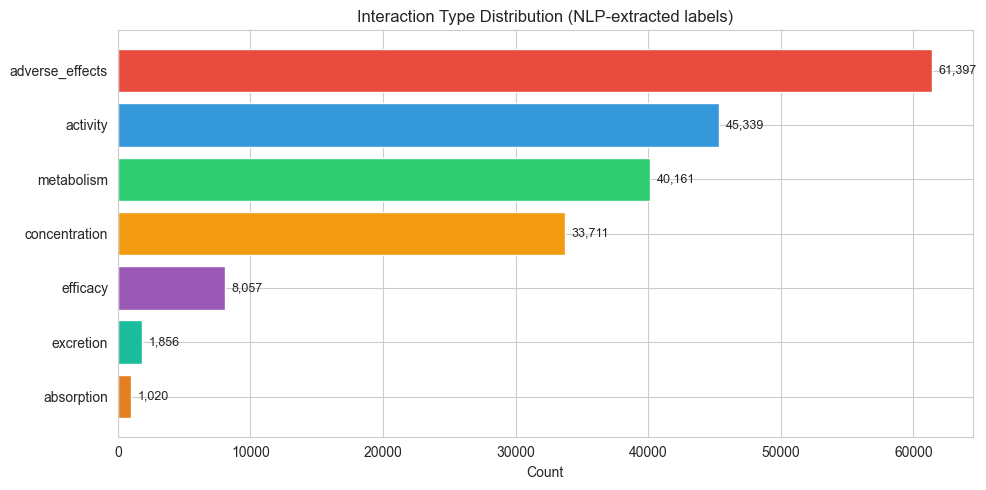

In [8]:
label_counts = df['label'].value_counts()
print("Label distribution:")
print("-" * 40)
for label, count in label_counts.items():
    print(f"  {label:>16s}: {count:>6,} ({count/n_total:.1%})")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
bars = ax.barh(label_counts.index[::-1], label_counts.values[::-1], color=colors[::-1])
ax.set_xlabel('Count')
ax.set_title('Interaction Type Distribution (NLP-extracted labels)')
for bar, val in zip(bars, label_counts.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Quick Graph Validation

Build the directed DDI graph and check basic network statistics to confirm data integrity.


In [9]:
import networkx as nx

# Drop any remaining unlabeled rows
df_labeled = df.dropna(subset=['label'])

# Build directed graph
G = nx.DiGraph()
for _, row in df_labeled.iterrows():
    G.add_edge(row['Drug 1'], row['Drug 2'], label=row['label'])

print("=== Graph Summary ===")
print(f"Nodes (drugs):       {G.number_of_nodes():,}")
print(f"Edges (interactions): {G.number_of_edges():,}")
print(f"Density:              {nx.density(G):.6f}")
print(f"Weakly connected:     {nx.is_weakly_connected(G)}")
print(f"WCC components:       {nx.number_weakly_connected_components(G)}")


=== Graph Summary ===
Nodes (drugs):       1,701
Edges (interactions): 191,252
Density:              0.066138
Weakly connected:     False
WCC components:       2


### 5.1 Degree Distribution

In-degree:    mean=112.4, median=72, max=736
Out-degree:   mean=112.4, median=87, max=850
Total degree: mean=224.9, median=183, max=912


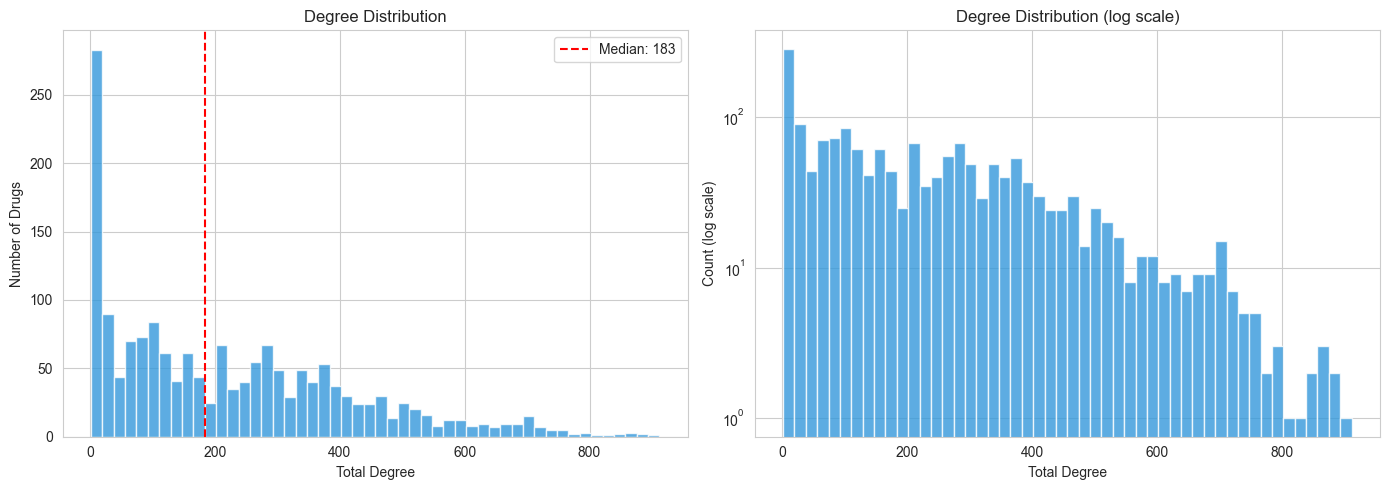

In [10]:
in_degs = [d for _, d in G.in_degree()]
out_degs = [d for _, d in G.out_degree()]
total_degs = [d for _, d in G.degree()]

print(f"In-degree:    mean={np.mean(in_degs):.1f}, median={np.median(in_degs):.0f}, max={max(in_degs)}")
print(f"Out-degree:   mean={np.mean(out_degs):.1f}, median={np.median(out_degs):.0f}, max={max(out_degs)}")
print(f"Total degree: mean={np.mean(total_degs):.1f}, median={np.median(total_degs):.0f}, max={max(total_degs)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(total_degs, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(np.median(total_degs), color='red', linestyle='--', label=f'Median: {np.median(total_degs):.0f}')
axes[0].set_xlabel('Total Degree')
axes[0].set_ylabel('Number of Drugs')
axes[0].set_title('Degree Distribution')
axes[0].legend()

axes[1].hist(total_degs, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Total Degree')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Degree Distribution (log scale)')

plt.tight_layout()
plt.show()


### 5.2 Top Drugs by Degree

In [11]:
total_deg = dict(G.degree())
top_drugs = sorted(total_deg.items(), key=lambda x: -x[1])[:15]

print("Top 15 drugs by total degree:")
print("-" * 45)
for drug, deg in top_drugs:
    print(f"  {drug:>25s}: {deg}")


Top 15 drugs by total degree:
---------------------------------------------
              Phenobarbital: 912
                  Phenytoin: 888
                  Primidone: 888
               Fosphenytoin: 870
              Carbamazepine: 858
                Venlafaxine: 858
                Fluvoxamine: 843
                 Amiodarone: 840
              Pentobarbital: 837
                 Nefazodone: 811
                  Diltiazem: 793
               Cyclosporine: 793
                Ziprasidone: 788
                Vemurafenib: 777
                  Clozapine: 771


### 5.3 Edge Label Distribution in Graph

In [12]:
edge_labels = [d['label'] for _, _, d in G.edges(data=True)]
label_counter = Counter(edge_labels)

print("Edge label distribution in graph:")
print("-" * 50)
for label, count in label_counter.most_common():
    print(f"  {label:>16s}: {count:>6,} ({count/len(edge_labels):.1%})")


Edge label distribution in graph:
--------------------------------------------------
   adverse_effects: 61,386 (32.1%)
          activity: 45,314 (23.7%)
        metabolism: 39,929 (20.9%)
     concentration: 33,701 (17.6%)
          efficacy:  8,051 (4.2%)
         excretion:  1,851 (1.0%)
        absorption:  1,020 (0.5%)


## 6. Save Processed Data

Save the labeled DataFrame for use in subsequent notebooks.


In [13]:
df_labeled.to_csv("../data/drug_interactions_labeled.csv", index=False)
print(f"Saved {len(df_labeled):,} labeled interactions to ../data/drug_interactions_labeled.csv")


Saved 191,541 labeled interactions to ../data/drug_interactions_labeled.csv


## Summary

**Key findings from Phase 1:**

| Metric | Value |
|--------|-------|
| Total interactions | 191,541 |
| Total unique drugs (nodes) | 1,701 |
| Graph edges | 191,246 |
| NLP label coverage | 99.997% |
| Interaction type classes | 7 |
| Top class (adverse_effects) | 32.1% |
| Smallest class (absorption) | 0.5% |

**Notes for downstream tasks:**
- Class imbalance is significant — use `class_weight='balanced'` in RF, weighted loss in GNN
- The graph is nearly fully weakly connected (2 components)
- High average degree (~225) means rich structural information per node
- Consider merging the 3 smallest classes (efficacy, excretion, absorption) into an "other" category if they hurt classifier performance

**Next:** Phase 2 — Graph Feature Engineering (notebook `02_nlp_label_extraction.ipynb` is merged into this notebook; proceed to `03_graph_construction.ipynb`)
